In [ ]:
import cv2
import numpy as np


In [ ]:
def random_transforms_batch(images):
    transformed_images = images.copy()
    for i in range(images.shape[0]):  # 遍历所有样本
        # 随机旋转
        angle = np.random.uniform(-30, 30)  # 随机旋转角度
        M = cv2.getRotationMatrix2D((20, 20), angle, 1)  # 以中心点旋转
        transformed_images[i] = cv2.warpAffine(images[i], M, (41, 41))
        #print(transformed_images[i].shape)
        # 随机缩放
        #scale_factor = np.random.uniform(0.8, 1.2)
        #transformed_images[i] = cv2.resize(transformed_images[i], None, fx=scale_factor, fy=scale_factor)

    return transformed_images


In [ ]:
def salt_and_pepper_noise_batch(images, salt_prob, pepper_prob):
    min_val = np.min(images)
    max_val = np.max(images)
    # 归一化操作，将数据范围从 [min_val, max_val] 映射到 [0, 1]
    images = (images - min_val) / (max_val - min_val)
    """为批量数据添加椒盐噪声"""
    noisy_images = images.copy()
    for i in range(images.shape[0]):  # 遍历所有样本
        total_pixels = 41*41
        # 添加盐（白点）噪声
        num_salt = int(salt_prob * total_pixels)
        salt_coords = [np.random.randint(0, j - 1, num_salt) for j in images[i].shape]
        noisy_images[i][salt_coords[0], salt_coords[1]] = 1

        # 添加胡椒（黑点）噪声
        num_pepper = int(pepper_prob * total_pixels)
        pepper_coords = [np.random.randint(0, j - 1, num_pepper) for j in images[i].shape]
        noisy_images[i][pepper_coords[0], pepper_coords[1]] = 0

    return noisy_images



In [ ]:
file_dir = r"D:\研三\大山1-毕业论文\代码\v41_data\train_data.npy"
data_np = np.load(file_dir)


In [ ]:
import random
import matplotlib.pyplot as plt
def plot_sample(normalized_images):
    
    # 随机抽取10张图片的索引
    random_indices = random.sample(range(normalized_images.shape[0]), 5)
    # 创建一个1x10的图像展示
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
    fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距
    # 打印每张图片的最大值及其位置，并显示图片
    for i, idx in enumerate(random_indices):
        image = normalized_images[idx]  # 获取第idx张图片

        # 获取最大值及其位置
        max_val = np.min(image)
        max_loc = np.unravel_index(np.argmin(image), image.shape)  # 获取最大值的位置

        # 打印图片的最大值及其位置
        print(f"Image {idx+1}:")
        print(f"Max Value: {max_val}, Location: {max_loc}")

        # 在对应的子图中显示图片，并设置颜色条范围为 [0, 1]
        im = axes[i].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]
        axes[i].set_title(f"Image {idx+1}")
        axes[i].axis('off')  # 关闭坐标轴

        # 添加颜色条
        plt.colorbar(im, ax=axes[i], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

    # 显示所有图片
    plt.show()

In [ ]:
plot_sample(data_np)

In [ ]:
import matplotlib.pyplot as plt
def sample_index(input_images):
    min_val = np.min(input_images)
    max_val = np.max(input_images)
    # 归一化操作，将数据范围从 [min_val, max_val] 映射到 [0, 1]
    normalized_images = (input_images - min_val) / (max_val - min_val)
    # 随机抽取10张图片的索引
    # 创建一个1x10的图像展示
    fig, axes = plt.subplots(5, 10, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
    axes = axes.flatten()
    fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距
    # 打印每张图片的最大值及其位置，并显示图片
    for idx in range(50):
        image = normalized_images[idx+100]  # 获取第idx张图片

        # 获取最大值及其位置
        max_val = np.min(image)
        max_loc = np.unravel_index(np.argmin(image), image.shape)  # 获取最大值的位置

        # 打印图片的最大值及其位置
        #print(f"Image {idx+1}:")
        #print(f"Max Value: {max_val}, Location: {max_loc}")

        # 在对应的子图中显示图片，并设置颜色条范围为 [0, 1]
        im = axes[idx].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]
        axes[idx].set_title(f"Image {idx+101}")
        axes[idx].axis('off')  # 关闭坐标轴

        # 添加颜色条
        plt.colorbar(im, ax=axes[idx], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

    # 显示所有图片
    plt.show()

sample_index(data_np)

In [ ]:
type(data_np)

In [ ]:
plot_sample(data_np)

In [ ]:
noise = salt_and_pepper_noise_batch(data_np,salt_prob=0.01,pepper_prob=0.01)
plot_sample(noise)

In [ ]:
import torch
from Network import VAE_41

# 加载模型权重
model = VAE_41()   # 这里应该是你的模型定义
model.load_state_dict(torch.load('./weight/size41_0119test.pth'))  # 加载预训练的权重
model.eval()  # 切换到评估模式

In [ ]:
import matplotlib.pyplot as plt
def l3_per_sample(x_recon, x, target_pos=(20, 20)):
    x_loc, y_loc = target_pos
    # 适配 (B,1,H,W)；如果你是 (B,H,W) 把 [:,0,...] 改成 [:,...]
    delta = (x_recon[:, 0, x_loc, y_loc] - x[:, 0, x_loc, y_loc])  # shape: (B,)
    xnor = x[:, 0, x_loc, y_loc]  # 避免除0
    return delta / xnor  # (B,)

# 随机挑 batch 里的 K 个样本展示
def show_recon_with_l3(model, loader, device, K=5, target_pos=(20,20), vmin=None, vmax=None, cmap='viridis'):
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        # 适配你的 DataLoader 输出：有的返回 (x, y)，有的只返回 x
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        x = x.to(device)

        # 前向推理（按你 VAE 的 forward 返回来改）
        out = model(x)
        if isinstance(out, (list, tuple)):
            # 常见：x_recon, mu, logvar
            x_recon = out[0]
        else:
            x_recon = out

        l3_vals = l3_per_sample(x_recon, x, target_pos=target_pos).detach().cpu()

        # 从 batch 里挑 K 个索引
        B = x.size(0)
        K = min(K, B)
        idxs = torch.randperm(B)[:K]

        for i, idx in enumerate(idxs):
            ori = x[idx, 0].detach().cpu()
            rec = x_recon[idx, 0].detach().cpu()
            l3  = float(l3_vals[idx])

            plt.figure(figsize=(8, 3))
            plt.suptitle(f"sample={int(idx)}   L3@{target_pos}={l3:.6f}")

            plt.subplot(1, 2, 1)
            plt.title("Original")
            plt.imshow(ori, cmap=cmap, vmin=vmin, vmax=vmax)
            #plt.scatter([target_pos[1]], [target_pos[0]], s=30)  # 标一下(20,20)
            plt.colorbar()

            plt.subplot(1, 2, 2)
            plt.title("Reconstruction")
            plt.imshow(rec, cmap=cmap, vmin=vmin, vmax=vmax)
            #plt.scatter([target_pos[1]], [target_pos[0]], s=30)
            plt.colorbar()

            plt.tight_layout()
            plt.show()




In [ ]:
batch_size = 64
data_np = torch.from_numpy(noise).float()
data_input = data_np.unsqueeze(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
data_input = data_input.to(device)
from torch.utils.data import random_split
from torch.utils.data import DataLoader
train_dataset, val_dataset = random_split(
    data_input, 
    [800, 200],
    generator=torch.Generator().manual_seed(42) 
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 用法：看训练集或验证集随便说明
show_recon_with_l3(model, train_loader, device, K=5, target_pos=(20,20), vmin=0, vmax=1, cmap='viridis')

In [ ]:
indices_to_remove = np.arange(12, 1000, 11) 
file_dir = r"D:\研三\大山1-毕业论文\代码\v41_data\train_data.npy"
data_te = np.load(file_dir)
data_cleaned = np.delete(data_te, indices_to_remove, axis=0)
print(data_cleaned.shape)



In [47]:
def standarlized(input_images):    
    min_val = np.min(input_images)
    max_val = np.max(input_images)
    # 归一化操作，将数据范围从 [min_val, max_val] 映射到 [0, 1]
    normalized_images = (input_images - min_val) / (max_val - min_val)
    return normalized_images

data_clean = standarlized(data_cleaned)

In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# =========================
# 0) 你需要准备的变量：
# - data_input: (1000,1,41,41) numpy 或 torch
# - model_path: 权重路径
# - load_model(model_path, device): 你已有的加载函数
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) 取前500条（保持原始顺序）
x500 = data_clean[:500]  # (500,1,41,41)

# 2) 转成 torch.Tensor
if isinstance(x500, np.ndarray):
    x500 = torch.from_numpy(x500)
x500 = x500.float()
x500 = x500.unsqueeze(1)
print(x500.shape)



torch.Size([500, 1, 41, 41])


In [51]:
# 3) 只加载一次模型
model.eval()

# 4) 批量推理拿到 z: (500,8)
bs = 128
Z_list = []
MU_list = []

with torch.no_grad():
    for i in range(0, x500.shape[0], bs):
        xb = x500[i:i+bs].to(device)  # (B,1,41,41)
        # 编码器输出
        mu, logvar = model.encode(xb)
        mu = mu.view(mu.shape[0], -1)   # 保证 (B,8)
        MU_list.append(mu.cpu())
        # 重参数化得到潜在向量
        #z = model.reparameterize(mu, logvar)
        # 有些实现会输出 (B,8,1,1)；这里统一拉平成 (B,8)
        #z = z.view(z.shape[0], -1)
        #Z_list.append(z.detach().cpu())
MU = torch.cat(MU_list, dim=0).numpy()
#Z = torch.cat(Z_list, dim=0).numpy()  # (500,8)
#print("Z shape =", Z.shape)

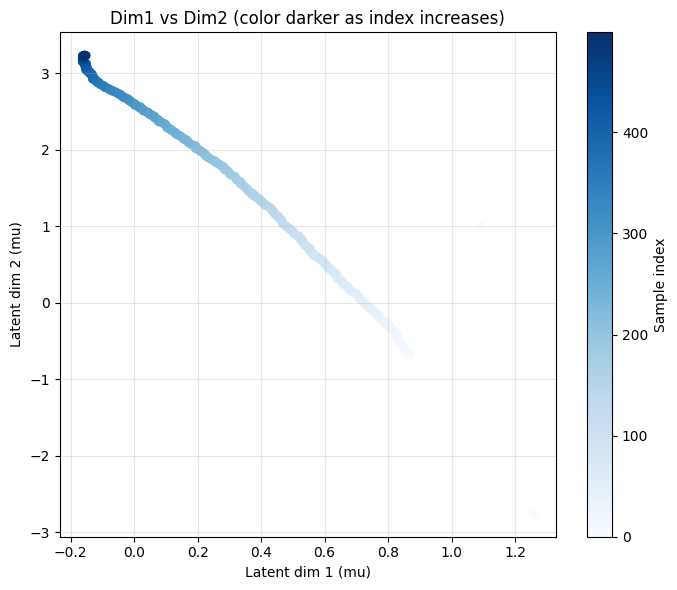

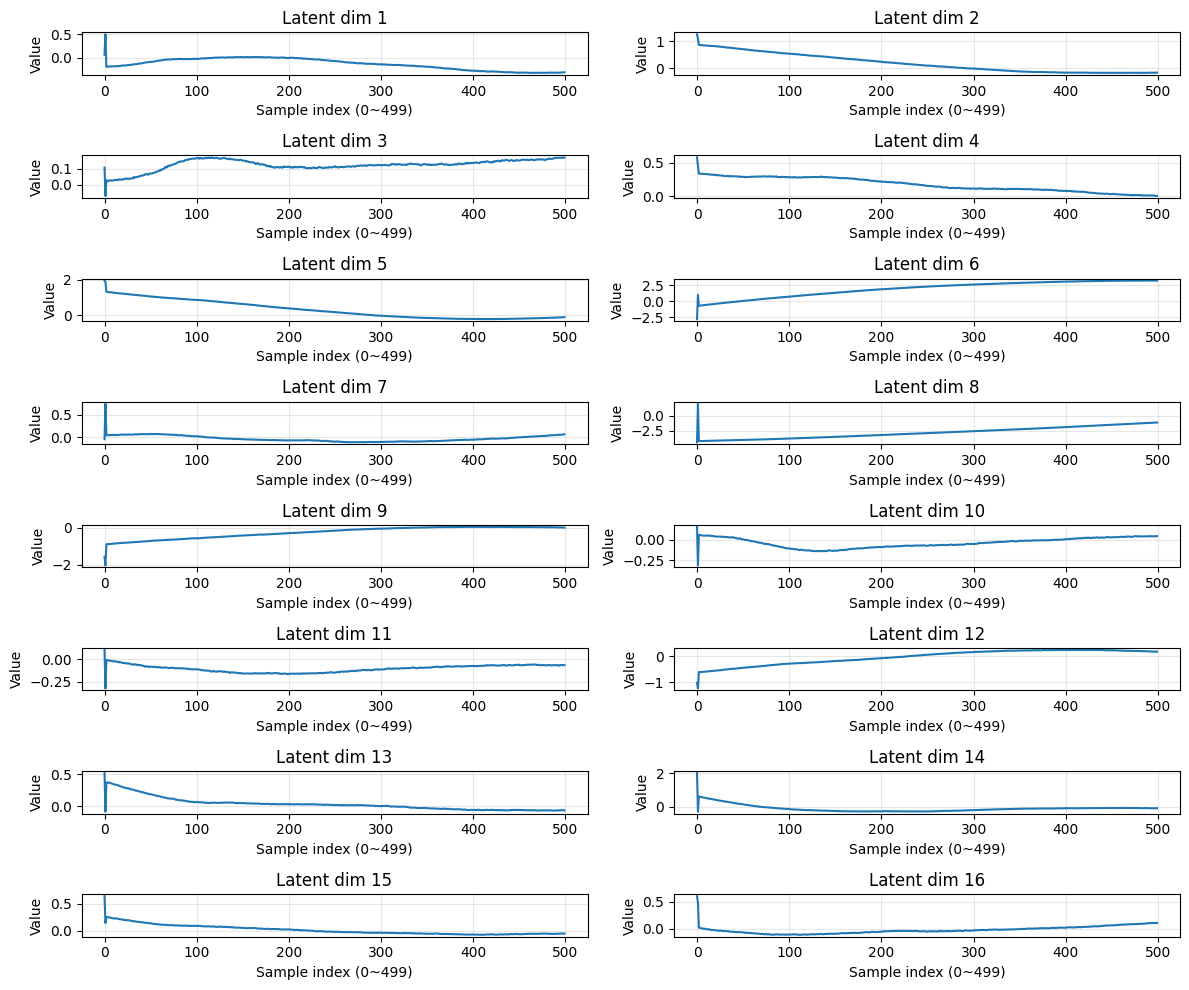

'\n# 6)（可选）再给你一个 500×8 的热力图，一眼看整体趋势\nplt.figure(figsize=(10, 5))\nplt.imshow(Z, aspect=\'auto\')\nplt.colorbar(label="Value")\nplt.xlabel("Latent dimension (0~7)")\nplt.ylabel("Sample index (0~499)")\nplt.title("Latent vectors heatmap (500x8)")\nplt.tight_layout()\nplt.show()\n'

In [52]:
idx = np.arange(MU.shape[0])  # 0~499，作为颜色
plt.figure(figsize=(7, 6))
sc = plt.scatter(MU[:, 1], MU[:, 5], c=idx, cmap="Blues", s=30)  # Blues: 越大越深
plt.colorbar(sc, label="Sample index")
plt.xlabel("Latent dim 1 (mu)")
plt.ylabel("Latent dim 2 (mu)")
plt.title("Dim1 vs Dim2 (color darker as index increases)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5) 画 8 个维度的趋势（8个子图）
x = np.arange(MU.shape[0])  # 0~499

plt.figure(figsize=(12, 10))
for k in range(16):
    ax = plt.subplot(8, 2, k + 1)
    ax.plot(x, MU[:, k])
    ax.set_title(f"Latent dim {k+1}")
    ax.set_xlabel("Sample index (0~499)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
'''
# 6)（可选）再给你一个 500×8 的热力图，一眼看整体趋势
plt.figure(figsize=(10, 5))
plt.imshow(Z, aspect='auto')
plt.colorbar(label="Value")
plt.xlabel("Latent dimension (0~7)")
plt.ylabel("Sample index (0~499)")
plt.title("Latent vectors heatmap (500x8)")
plt.tight_layout()
plt.show()
'''

主成分矩阵：
[[-0.04716478 -0.20057029  0.0114804  -0.06043565 -0.29633835  0.71012866
  -0.01709689  0.5416208   0.17939769  0.00979627  0.00150444  0.161504
  -0.05641837 -0.05833353 -0.05001558  0.02378143]
 [-0.11199185  0.11262397 -0.02276061 -0.01319227  0.20797944 -0.34919825
   0.13944577  0.76360387 -0.20940046  0.08273119  0.05723193 -0.16849212
   0.04346322  0.3216767   0.05404237  0.12532806]]
解释方差比例：
[0.9329576  0.05209638]


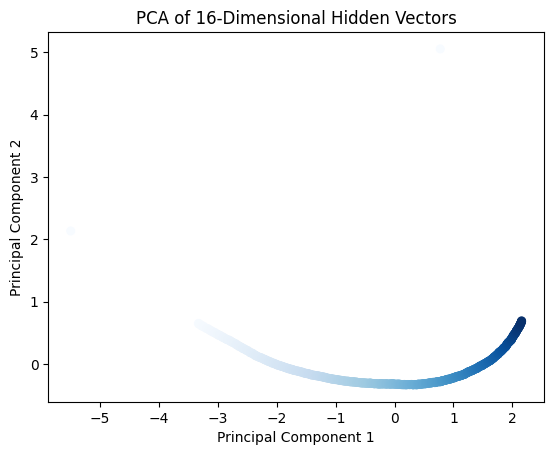

In [53]:
from sklearn.decomposition import PCA

# 创建 PCA 对象，选择保留的主成分数目，可以选择2个或者更多主成分
pca = PCA(n_components=2)  # 降维到 2 维

# 对数据进行主成分分析
reduced_data = pca.fit_transform(MU)

# 输出主成分
print("主成分矩阵：")
print(pca.components_)  # 每个主成分的方向
print("解释方差比例：")
print(pca.explained_variance_ratio_)  # 每个主成分解释的方差比例

# 绘制降维后的数据
idx = np.arange(MU.shape[0])
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=idx, cmap="Blues", s=30)
plt.title('PCA of 16-Dimensional Hidden Vectors')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
